# CS 6476 Project 1: Image Filtering and Hybrid Images

All projects in this course will be done with these iPython notebooks. These are convenient ways for you to quickly and easily interact with the code. A notebook contains many blocks of code, each of which can be run independently. You can run a cell with ctrl+enter or shift+enter (to move to the next cell).

If there are any notes you wish to leave for the TAs as they test your code, you may leave them here.

## Setup

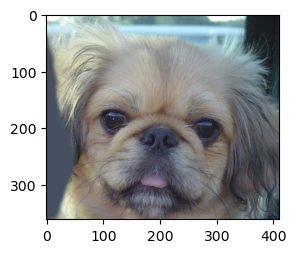

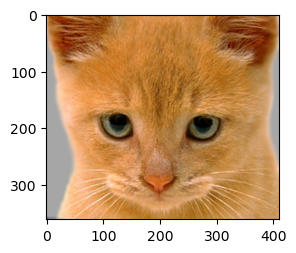

In [1]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from utils import vis_hybrid_image, load_image, save_image, im_range
from student_code import my_imfilter, create_hybrid_image
%load_ext autoreload
%autoreload 2

image1 = load_image('../data/dog.bmp')
image2 = load_image('../data/cat.bmp')

# display the dog and cat images
plt.figure(figsize=(3,3)); plt.imshow((image1*255).astype(np.uint8));
plt.figure(figsize=(3,3)); plt.imshow((image2*255).astype(np.uint8));

## Create filter

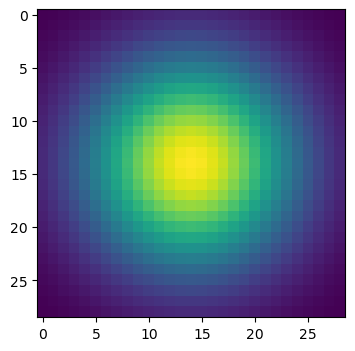

In [2]:
cutoff_frequency = 7
filter = cv2.getGaussianKernel(ksize=cutoff_frequency*4+1,
                               sigma=cutoff_frequency)
filter = np.dot(filter, filter.T)

# let's take a look at the filter!
plt.figure(figsize=(4,4)); plt.imshow(filter);

## Apply filter to image
Both functions you need to implement in this project can be found in _student_\__code.py_. Start by implementing _my_\__imfilter_, which takes both a filter and an image, and returns the filtered image. This code block will use your _my_\__imfilter_ function to create and display a blurry version of the dog image.

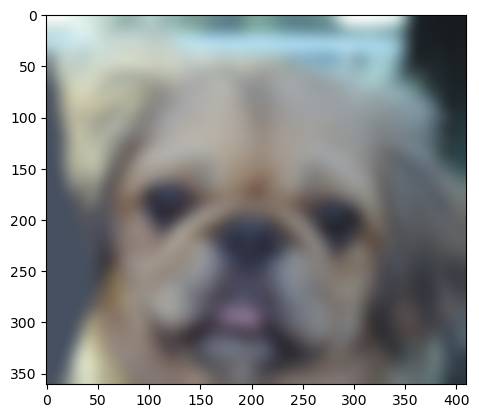

In [3]:
blurry_dog = my_imfilter(image1, filter)
plt.figure(); plt.imshow((blurry_dog*255).astype(np.uint8));

## Create hybrid image
Next, implement _create_\__hybrid_\__image_, which takes two images and makes a hybrid image using the low frequency content from one image and the high frequency content from another.

In [4]:
low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter)
vis = vis_hybrid_image(hybrid_image)

## Show results

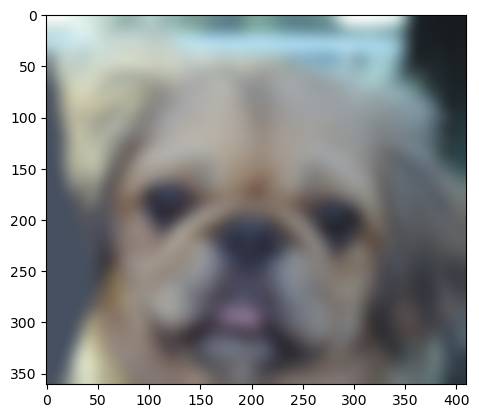

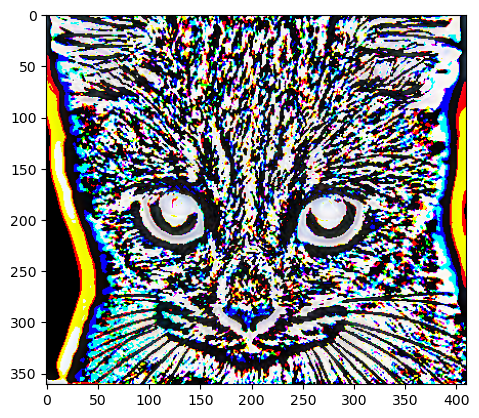

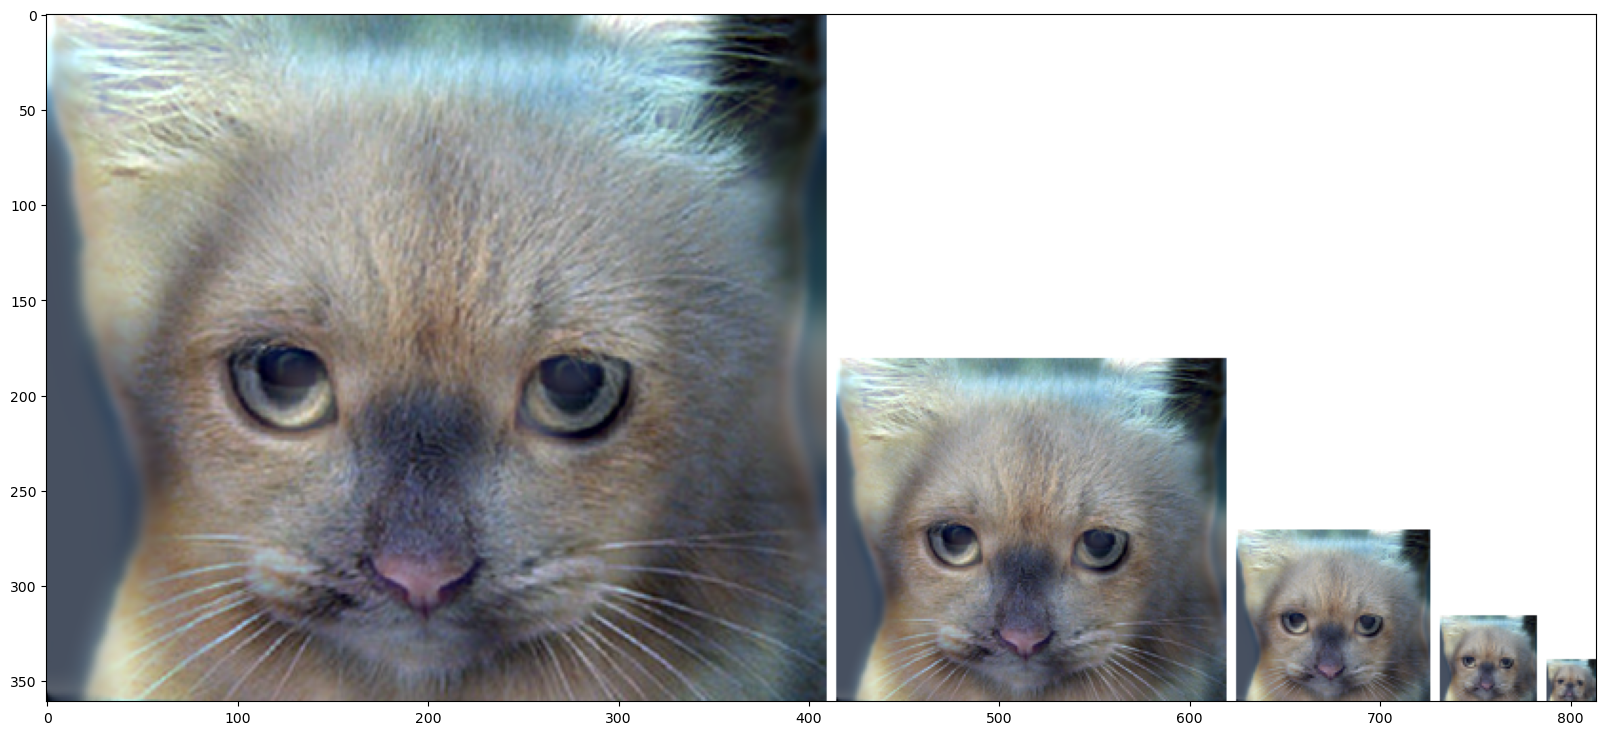

In [5]:
# 检查高频、低频图像是否正确，若不正确请检查是否已调整图像强度值到[0,1]范围内
plt.figure(); plt.imshow((low_frequencies*255).astype(np.uint8));
plt.figure(); plt.imshow((high_frequencies*255).astype(np.uint8));
plt.figure(figsize=(20, 20)); plt.imshow(vis);

## Save results

In [6]:
save_image('../results/low_frequencies.jpg', low_frequencies)
save_image('../results/high_frequencies.jpg', high_frequencies)
save_image('../results/hybrid_image.jpg', hybrid_image)
save_image('../results/hybrid_image_scales.jpg', vis)

True

## Extra Credit: Parameter Tuning Study

请在下面代码单元的 `EXTRA_PAIRS` 中填写图片路径。

推荐准备数量：
- 最少 2 张（1 对）：可做基础 extra credit
- 推荐 6 张（3 对）：更容易拿满附加分（2 对课程内置 + 1 对自定义）

建议规则：
1. 每对图像必须已经对齐且尺寸一致
2. 每对图像命名清晰，便于写报告
3. 路径统一放在 `../data/` 下，方便打包和复现

Extra credit results generated:
('dog_cat', 2, '../results/extra_credit\\dog_cat\\cutoff_2_hybrid_scales.jpg')
('dog_cat', 4, '../results/extra_credit\\dog_cat\\cutoff_4_hybrid_scales.jpg')
('dog_cat', 6, '../results/extra_credit\\dog_cat\\cutoff_6_hybrid_scales.jpg')
('dog_cat', 8, '../results/extra_credit\\dog_cat\\cutoff_8_hybrid_scales.jpg')
('submarine_fish', 2, '../results/extra_credit\\submarine_fish\\cutoff_2_hybrid_scales.jpg')
('submarine_fish', 4, '../results/extra_credit\\submarine_fish\\cutoff_4_hybrid_scales.jpg')
('submarine_fish', 6, '../results/extra_credit\\submarine_fish\\cutoff_6_hybrid_scales.jpg')
('submarine_fish', 8, '../results/extra_credit\\submarine_fish\\cutoff_8_hybrid_scales.jpg')
('bird_plane', 2, '../results/extra_credit\\bird_plane\\cutoff_2_hybrid_scales.jpg')
('bird_plane', 4, '../results/extra_credit\\bird_plane\\cutoff_4_hybrid_scales.jpg')
('bird_plane', 6, '../results/extra_credit\\bird_plane\\cutoff_6_hybrid_scales.jpg')
('bird_plane', 8, '../res

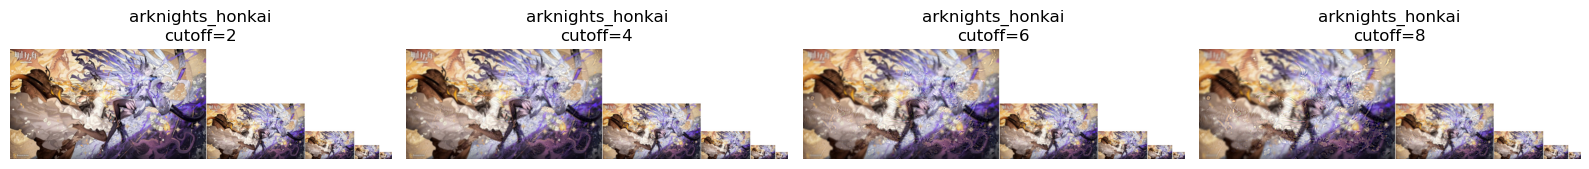

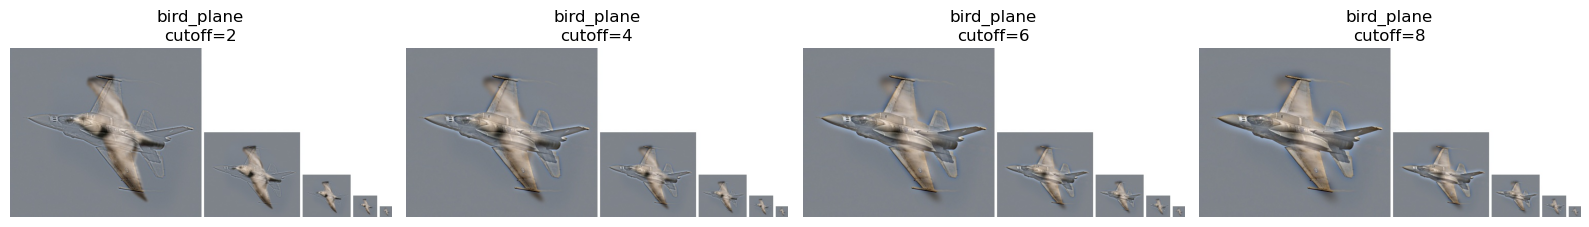

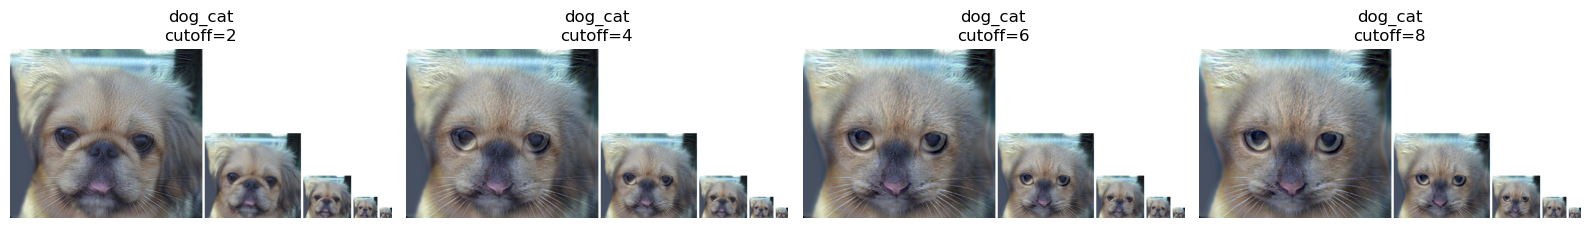

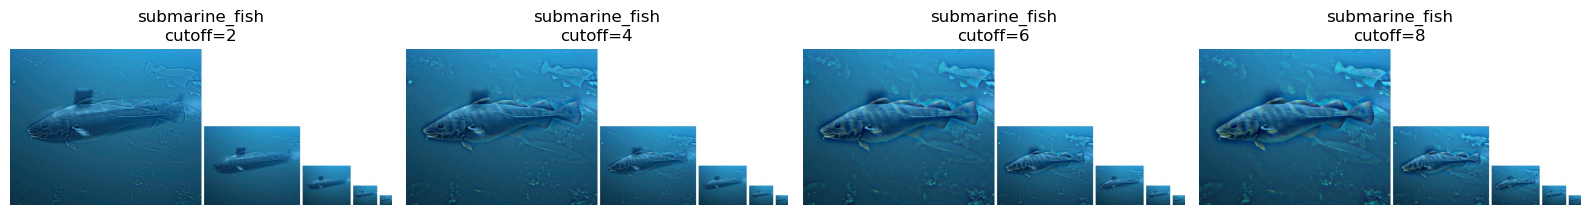

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import vis_hybrid_image, load_image, save_image
from student_code import create_hybrid_image

# ===== 在这里填写你要测试的图片对 =====
# 格式: (pair_name, image1_path, image2_path)
# 路径放在 ../data/ 下
EXTRA_PAIRS = [
    ('dog_cat', '../data/dog.bmp', '../data/cat.bmp'),
    # 推荐再加两对以冲击附加分上限：
    ('submarine_fish', '../data/submarine.bmp', '../data/fish.bmp'),
    ('bird_plane', '../data/bird.bmp', '../data/plane.bmp'),
    ('arknights_honkai', '../data/arknights.png', '../data/Honkai_Starrail.jpg'),
]

# 调参集合：你可以改成 [1, 2, 3, 4, 5, 6, 7, 8]
CUTOFF_LIST = [2, 4, 6, 8]

# 输出目录
extra_dir = '../results/extra_credit'
os.makedirs(extra_dir, exist_ok=True)

summary = []
skipped = []

for pair_name, img1_path, img2_path in EXTRA_PAIRS:
    if (not os.path.exists(img1_path)) or (not os.path.exists(img2_path)):
        skipped.append((pair_name, 'missing file'))
        continue

    image1 = load_image(img1_path)
    image2 = load_image(img2_path)

    if image1.shape != image2.shape:
        skipped.append((pair_name, f'shape mismatch: {image1.shape} vs {image2.shape}'))
        continue

    pair_dir = os.path.join(extra_dir, pair_name)
    os.makedirs(pair_dir, exist_ok=True)

    for cutoff_frequency in CUTOFF_LIST:
        g = cv2.getGaussianKernel(ksize=cutoff_frequency * 4 + 1, sigma=cutoff_frequency)
        filter = np.dot(g, g.T)

        low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter)
        vis = vis_hybrid_image(hybrid_image)

        prefix = os.path.join(pair_dir, f'cutoff_{cutoff_frequency}')
        save_image(prefix + '_low.jpg', low_frequencies)
        save_image(prefix + '_high.jpg', high_frequencies)
        save_image(prefix + '_hybrid.jpg', hybrid_image)
        save_image(prefix + '_hybrid_scales.jpg', vis)

        summary.append((pair_name, cutoff_frequency, prefix + '_hybrid_scales.jpg'))

print('Extra credit results generated:')
for item in summary:
    print(item)

if skipped:
    print('\nSkipped pairs:')
    for item in skipped:
        print(item)

# 额外可视化：展示每一对图像在不同 cutoff 下的 hybrid_scales
valid_pairs = sorted(set([p for p, _, _ in summary]))
for pair_name in valid_pairs:
    plt.figure(figsize=(16, 4))
    plot_idx = 1
    for cutoff_frequency in CUTOFF_LIST:
        path = os.path.join(extra_dir, pair_name, f'cutoff_{cutoff_frequency}_hybrid_scales.jpg')
        if not os.path.exists(path):
            continue
        vis_img = load_image(path)
        plt.subplot(1, len(CUTOFF_LIST), plot_idx)
        plt.imshow((vis_img * 255).astype(np.uint8))
        plt.title(f'{pair_name}\ncutoff={cutoff_frequency}')
        plt.axis('off')
        plot_idx += 1
    plt.tight_layout()
    plt.show()

In [8]:
import os
from utils import load_image


bird = load_image('../data/bird.bmp')
fish = load_image('../data/fish.bmp')
bicycle = load_image('../data/bicycle.bmp')
einstein = load_image('../data/einstein.bmp')
marilyn = load_image('../data/marilyn.bmp')
motorcycle = load_image('../data/motorcycle.bmp')
plane= load_image('../data/plane.bmp')
submarine = load_image('../data/submarine.bmp')
arknights= load_image('../data/arknights.png')
Honkai_Starrail= load_image('../data/Honkai_Starrail.jpg')
print('bird shape:', bird.shape)
print('fish shape:', fish.shape)
print('bicycle shape:', bicycle.shape)
print('einstein shape:', einstein.shape)
print('marilyn shape:', marilyn.shape)
print('motorcycle shape:', motorcycle.shape)
print('plane shape:', plane.shape)
print('submarine shape:', submarine.shape)
print('arknights shape:', arknights.shape)
print('Honkai_Starrail shape:', Honkai_Starrail.shape)

bird shape: (331, 375, 3)
fish shape: (307, 375, 3)
bicycle shape: (300, 453, 3)
einstein shape: (265, 225, 3)
marilyn shape: (265, 225, 3)
motorcycle shape: (300, 453, 3)
plane shape: (331, 375, 3)
submarine shape: (307, 375, 3)
arknights shape: (1080, 1920, 3)
Honkai_Starrail shape: (1080, 1920, 3)
